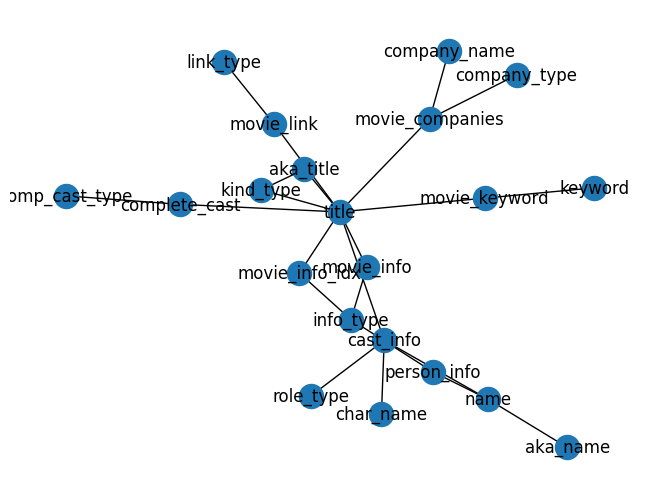

In [19]:
%matplotlib inline
from workload.workloads import get_workload_set
import networkx as nx
import matplotlib.pyplot as plt
import duckdb
import lark

workload_set = get_workload_set("JOB")

join_graph = workload_set.join_graph
nx.draw(join_graph, with_labels=True)

# One Predicate, Full Schema

In [8]:
def grammar_for_table(table):    
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    filter_rules = []
    filter_names = []
    for _, d in cols.iterrows():
        cname = d["column_name"]
        if cname.endswith("_id"):
            continue
        ctype = d["column_type"]
    
        filt_rule = f"{table}_{cname}_filter"
        if ctype == "VARCHAR":
            filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
        elif ctype == "INTEGER":
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            
        filter_names.append(filt_rule)
    
    grammar = [
        # f"""{table}_selector: "({table} " {" ".join(x + '?' for x in filter_names)} ")" """
        f"{table}_filtered: {table}_selector " + "".join(f""""({t} )"? """ for t in workload_set.tables if t != table),
        f"{table}_selector: " + " | ".join(f""""({table} " {filter_name} ")" """ for filter_name in filter_names)
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

con = duckdb.connect("imdb.duckdb")
restricted_predicates_grammar = ["start: " + " | ".join(f"{t}_filtered" for t in workload_set.tables)]
for table in workload_set.tables:
    restricted_predicates_grammar.extend(grammar_for_table(table))

restricted_predicates_grammar_str = "\n".join(restricted_predicates_grammar)
restricted_predicates_grammar_str += """

intop: "<" | ">" | "=" | "!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(restricted_predicates_grammar_str)

start: aka_name_filtered | aka_title_filtered | cast_info_filtered | char_name_filtered | comp_cast_type_filtered | company_name_filtered | company_type_filtered | complete_cast_filtered | info_type_filtered | keyword_filtered | kind_type_filtered | link_type_filtered | movie_companies_filtered | movie_info_filtered | movie_info_idx_filtered | movie_keyword_filtered | movie_link_filtered | name_filtered | person_info_filtered | role_type_filtered | title_filtered
aka_name_filtered: aka_name_selector "(aka_title )"? "(cast_info )"? "(char_name )"? "(comp_cast_type )"? "(company_name )"? "(company_type )"? "(complete_cast )"? "(info_type )"? "(keyword )"? "(kind_type )"? "(link_type )"? "(movie_companies )"? "(movie_info )"? "(movie_info_idx )"? "(movie_keyword )"? "(movie_link )"? "(name )"? "(person_info )"? "(role_type )"? "(title )"? 
aka_name_selector: "(aka_name " aka_name_name_filter ")"  | "(aka_name " aka_name_imdb_index_filter ")"  | "(aka_name " aka_name_name_pcode_cf_filter "

# Restricted Schema: 2 Hops
We opted for name over title because 19/21 tables are within 2 hops of title.

Tables within 2 hops of 'name': ['aka_name', 'cast_info', 'char_name', 'info_type', 'name', 'person_info', 'role_type', 'title']
Total tables (2 hops): 8 (out of 21)


Text(0.5, 1.0, "Graph within 2 hops of 'name'")

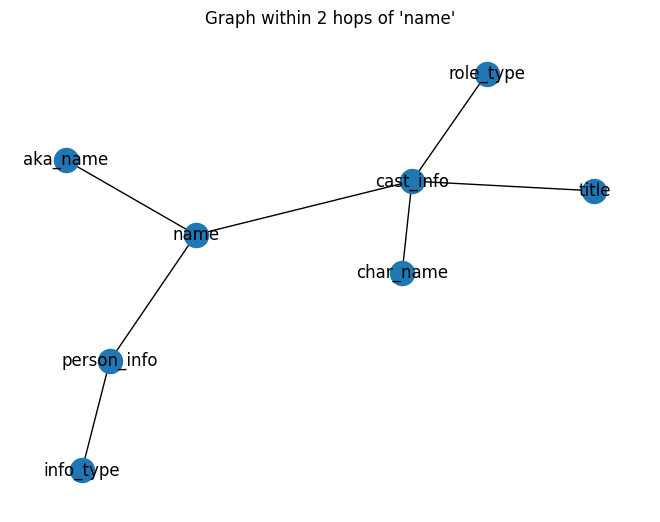

In [6]:
# Schema graphs within 2 hops of `name`

paths_from_name_2 = nx.single_source_shortest_path_length(join_graph, 'name', cutoff=2)
restricted_tables_2 = set(paths_from_name_2.keys())

print(f"Tables within 2 hops of 'name': {sorted(restricted_tables_2)}")
print(f"Total tables (2 hops): {len(restricted_tables_2)} (out of {len(join_graph.nodes())})")

# Create subgraph with only the 2-hop restricted tables
restricted_join_graph_2 = join_graph.subgraph(restricted_tables_2).copy()

nx.draw(restricted_join_graph_2, with_labels=True)
plt.title("Graph within 2 hops of 'name'")


In [22]:
# Restricted Schema Grammar with Arbitrary Predicates

def grammar_for_table_arbitrary(table):    
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    filter_rules = []
    filter_names = []
    for _, d in cols.iterrows():
        cname = d["column_name"]
        if cname.endswith("_id"):
            continue
        ctype = d["column_type"]
    
        filt_rule = f"{table}_{cname}_filter"
        if ctype == "VARCHAR":
            filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
        elif ctype == "INTEGER":
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            
        filter_names.append(filt_rule)
    
    # Use optional predicates (?) to allow arbitrary number of filters per table
    grammar = [
        f"""{table}_selector: "({table} " {" ".join(x + '?' for x in filter_names)} ")" """
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

# Generate grammar for restricted tables (2 hops from 'name')
restricted_schema_grammar = ["start: " + " ".join(f"{x}_selector?" for x in sorted(restricted_tables_2))]
for table in sorted(restricted_tables_2):
    restricted_schema_grammar.extend(grammar_for_table_arbitrary(table))

restricted_schema_grammar_str = "\n".join(restricted_schema_grammar)
restricted_schema_grammar_str += """

intop: "<" | ">" | "=" | "!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(restricted_schema_grammar_str)


start: aka_name_selector? cast_info_selector? char_name_selector? info_type_selector? name_selector? person_info_selector? role_type_selector? title_selector?
aka_name_selector: "(aka_name " aka_name_name_filter? aka_name_imdb_index_filter? aka_name_name_pcode_cf_filter? aka_name_name_pcode_nf_filter? aka_name_surname_pcode_filter? aka_name_md5sum_filter? ")" 
aka_name_name_filter: "(name " strop ")" 
aka_name_imdb_index_filter: "(imdb_index " strop ")" 
aka_name_name_pcode_cf_filter: "(name_pcode_cf " strop ")" 
aka_name_name_pcode_nf_filter: "(name_pcode_nf " strop ")" 
aka_name_surname_pcode_filter: "(surname_pcode " strop ")" 
aka_name_md5sum_filter: "(md5sum " strop ")" 

cast_info_selector: "(cast_info " cast_info_note_filter? cast_info_nr_order_filter? ")" 
cast_info_note_filter: "(note " strop ")" 
cast_info_nr_order_filter: "(nr_order " intop " " intval ")" 

char_name_selector: "(char_name " char_name_name_filter? char_name_imdb_index_filter? char_name_name_pcode_nf_filter? c

In [23]:
# Just testing the grammar
restricted_schema_lark = lark.Lark(restricted_schema_grammar_str)
restricted_schema_lark.parse("(name )(title (title random))")

Tree(Token('RULE', 'start'), [Tree(Token('RULE', 'name_selector'), []), Tree(Token('RULE', 'title_selector'), [Tree(Token('RULE', 'title_title_filter'), [Tree(Token('RULE', 'strop'), [])])])])

# One Predicate, Restricted Schema

In [26]:
# Restricted Schema Grammar with Single Predicate Only

def grammar_for_table_single(table):    
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    filter_rules = []
    filter_names = []
    for _, d in cols.iterrows():
        cname = d["column_name"]
        if cname.endswith("_id"):
            continue
        ctype = d["column_type"]
    
        filt_rule = f"{table}_{cname}_filter"
        if ctype == "VARCHAR":
            filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
        elif ctype == "INTEGER":
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            
        filter_names.append(filt_rule)
    
    # Use | (OR) to allow only ONE filter per table selector
    grammar = [
        f"{table}_filtered: {table}_selector " + "".join(f""""({t} )"? """ for t in sorted(restricted_tables_2) if t != table),
        f"{table}_selector: " + " | ".join(f""""({table} " {filter_name} ")" """ for filter_name in filter_names)
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

# Generate grammar for restricted tables (2 hops from 'name') with single predicate only
restricted_everything_grammar = ["start: " + " | ".join(f"{t}_filtered" for t in sorted(restricted_tables_2))]
for table in sorted(restricted_tables_2):
    restricted_everything_grammar.extend(grammar_for_table_single(table))

restricted_everything_grammar_str = "\n".join(restricted_everything_grammar)
restricted_everything_grammar_str += """

intop: "<" | ">" | "=" | "!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(restricted_everything_grammar_str)


start: aka_name_filtered | cast_info_filtered | char_name_filtered | info_type_filtered | name_filtered | person_info_filtered | role_type_filtered | title_filtered
aka_name_filtered: aka_name_selector "(cast_info )"? "(char_name )"? "(info_type )"? "(name )"? "(person_info )"? "(role_type )"? "(title )"? 
aka_name_selector: "(aka_name " aka_name_name_filter ")"  | "(aka_name " aka_name_imdb_index_filter ")"  | "(aka_name " aka_name_name_pcode_cf_filter ")"  | "(aka_name " aka_name_name_pcode_nf_filter ")"  | "(aka_name " aka_name_surname_pcode_filter ")"  | "(aka_name " aka_name_md5sum_filter ")" 
aka_name_name_filter: "(name " strop ")" 
aka_name_imdb_index_filter: "(imdb_index " strop ")" 
aka_name_name_pcode_cf_filter: "(name_pcode_cf " strop ")" 
aka_name_name_pcode_nf_filter: "(name_pcode_nf " strop ")" 
aka_name_surname_pcode_filter: "(surname_pcode " strop ")" 
aka_name_md5sum_filter: "(md5sum " strop ")" 

cast_info_filtered: cast_info_selector "(aka_name )"? "(char_name )"? "

In [32]:
restricted_everything_lark = lark.Lark(restricted_everything_grammar_str)
restricted_everything_lark.parse("(title (title random))(name )")
try:
    restricted_everything_lark.parse("(title (title random))(name (gender most_popular))")
    restricted_everything_lark.parse("(title (title random))(name )(cast_info (note random))")
    assert False
except lark.exceptions.LarkError as e:
    pass
